In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
# Transform images to tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load training and test data
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Create data loaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

print("Training samples:", len(train_data))
print("Test samples:", len(test_data))

100%|██████████| 9.91M/9.91M [00:00<00:00, 23.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.09MB/s]

Training samples: 60000
Test samples: 10000


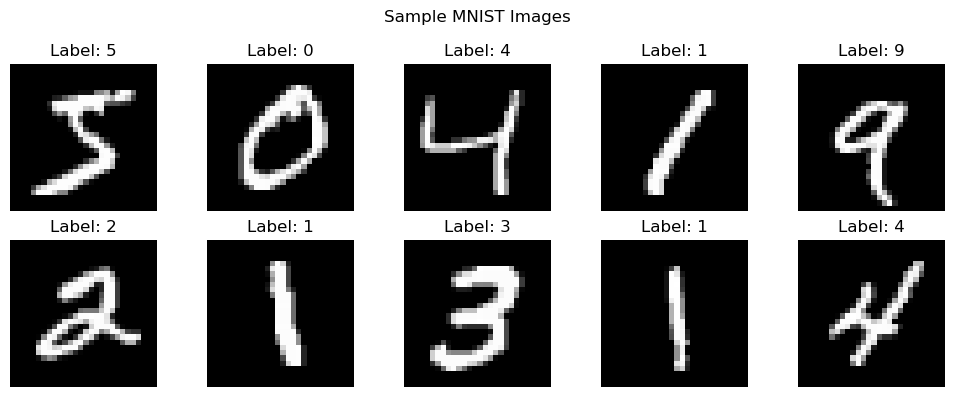

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout()
plt.show()

In [4]:
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(784, 128)  # input layer: 784 pixels → 128 neurons
        self.fc2 = nn.Linear(128, 64)   # hidden layer: 128 → 64 neurons
        self.fc3 = nn.Linear(64, 10)    # output layer: 64 → 10 digits
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 784)            # flatten image to 784 numbers
        x = self.relu(self.fc1(x))     # layer 1 + ReLU
        x = self.relu(self.fc2(x))     # layer 2 + ReLU
        x = self.fc3(x)                # output layer (no ReLU)
        return x

model = NeuralNet()
print(model)

NeuralNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer ready!")

Loss function and optimizer ready!


In [6]:
epochs = 5  # number of times to loop through all 60,000 images

for epoch in range(epochs):
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()          # clear gradients from last step
        outputs = model(images)        # forward pass: get predictions
        loss = criterion(outputs, labels)  # calculate loss
        loss.backward()                # backward pass: calculate gradients
        optimizer.step()               # update weights
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/5, Loss: 0.3984
Epoch 2/5, Loss: 0.1915
Epoch 3/5, Loss: 0.1413
Epoch 4/5, Loss: 0.1134
Epoch 5/5, Loss: 0.0949


In [7]:
correct = 0
total = 0

model.eval()  # switch to evaluation mode

with torch.no_grad():  # don't calculate gradients during testing
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)  # pick highest scoring digit
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 96.67%


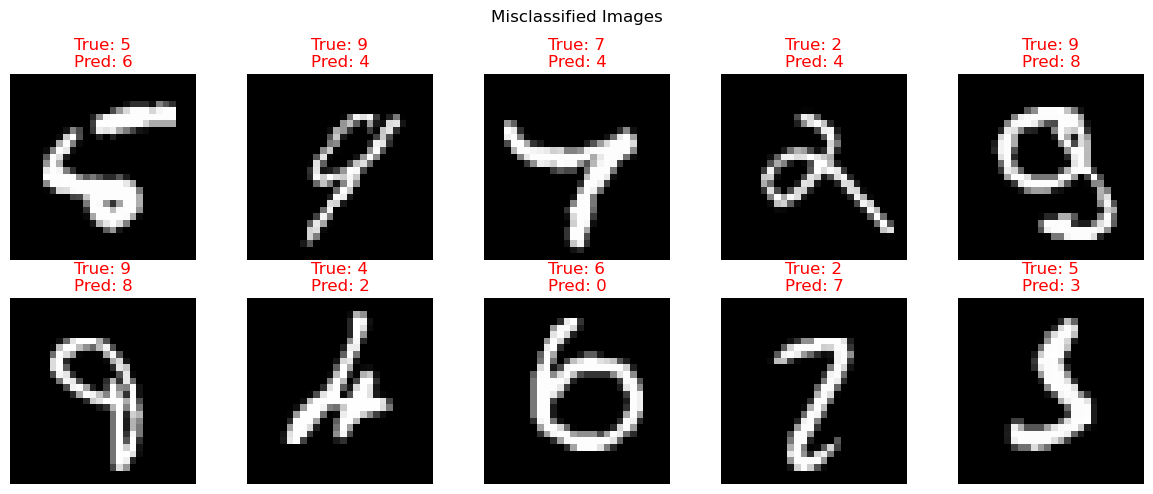

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
misclassified = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified.append((images[i], labels[i].item(), predicted[i].item()))
        if len(misclassified) >= 10:
            break

for i, ax in enumerate(axes.flatten()):
    img, true, pred = misclassified[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'True: {true}\nPred: {pred}', color='red')
    ax.axis('off')

plt.suptitle('Misclassified Images')
plt.tight_layout()
plt.show()

In [9]:
import joblib
torch.save(model.state_dict(), 'mnist_model.pth')
print("Model saved!")

Model saved!
